In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn import tree
import graphviz
from sklearn.metrics import *

import warnings
warnings.filterwarnings('ignore')

In [ ]:
crypto = pd.read_csv('/content/crypto_scam_transaction_dataset.csv')
crypto

,transaction_id,timestamp,blockchain,transaction_type,sender_wallet_age_days,receiver_wallet_age_days,transaction_amount_usd,gas_fee_usd,token_type,platform,num_prev_transactions_sender,num_prev_transactions_receiver,avg_txn_interval_sender_min,is_cross_chain,failed_txn_ratio_sender,velocity_score,anomaly_score,is_scam
0,TX000001,1701692743,BSC,Mint,469,769,929.39,2.76,ERC20,Coinbase,1120,960,100.5,0,0.18,-0.12,0.11,0
1,TX000002,1704304572,Ethereum,Bridge,1076,1238,139.21,9.36,Stablecoin,Unknown DEX,1203,1011,170.9,1,0.01,0.01,0.10,1
2,TX000003,1704926484,BSC,Transfer,679,442,395.21,13.44,Native,OpenSea,1160,1054,7.7,1,0.14,0.10,0.12,0
3,TX000004,1702234489,Solana,Mint,1573,2434,2078.90,1.29,Stablecoin,Coinbase,1179,994,6.1,0,0.07,0.13,0.00,0
4,TX000005,1701570006,BSC,Swap,522,418,72.47,24.68,Stablecoin,Kraken,1177,968,194.7,0,0.30,0.01,0.20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,TX019996,1701696362,Polygon,Mint,178,73,4629.86,10.68,Meme,Kraken,1205,947,17.9,0,0.07,0.05,0.00,0
19996,TX019997,1700181393,Solana,Swap,421,1977,1863.93,8.74,ERC20,OpenSea,1176,1025,92.7,0,0.09,-0.02,0.05,0
19997,TX019998,1700745723,BSC,Swap,215,132,466.35,2.93,Stablecoin,Kraken,1195,1002,954.5,1,0.13,-0.00,0.21,1
19998,TX019999,1701253357,Ethereum,Bridge,325,278,440.27,2.74,Native,Kraken,1150,996,88.6,0,0.05,0.05,0.00,0


In [ ]:
crypto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  20000 non-null  object 
 1   timestamp                       20000 non-null  int64  
 2   blockchain                      20000 non-null  object 
 3   transaction_type                20000 non-null  object 
 4   sender_wallet_age_days          20000 non-null  int64  
 5   receiver_wallet_age_days        20000 non-null  int64  
 6   transaction_amount_usd          20000 non-null  float64
 7   gas_fee_usd                     19400 non-null  float64
 8   token_type                      20000 non-null  object 
 9   platform                        19400 non-null  object 
 10  num_prev_transactions_sender    20000 non-null  int64  
 11  num_prev_transactions_receiver  20000 non-null  int64  
 12  avg_txn_interval_sender_min     

In [ ]:
crypto.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,20000.0,1.702510e+09,1.442829e+06,1.700000e+09,1.701262e+09,1.702508e+09,1.703769e+09,1.705000e+09
sender_wallet_age_days,20000.0,6.046363e+02,5.995499e+02,0.000000e+00,1.740000e+02,4.160000e+02,8.500000e+02,5.497000e+03
receiver_wallet_age_days,20000.0,5.007058e+02,5.048955e+02,0.000000e+00,1.430000e+02,3.450000e+02,6.880000e+02,4.542000e+03
transaction_amount_usd,20000.0,7.466849e+02,1.075765e+03,6.730000e+00,1.889025e+02,4.061750e+02,8.546600e+02,2.322062e+04
gas_fee_usd,19400.0,1.019214e+01,9.878027e+00,3.600000e-01,4.310000e+00,7.330000e+00,1.264000e+01,2.411100e+02
num_prev_transactions_sender,20000.0,1.199994e+03,3.457564e+01,1.073000e+03,1.176000e+03,1.200000e+03,1.223000e+03,1.346000e+03
num_prev_transactions_receiver,20000.0,1.000247e+03,3.152142e+01,8.770000e+02,9.790000e+02,1.000000e+03,1.021000e+03,1.130000e+03
avg_txn_interval_sender_min,19400.0,2.408361e+02,2.992739e+02,2.600000e+00,7.550000e+01,1.472000e+02,2.889000e+02,4.844700e+03
is_cross_chain,20000.0,1.800000e-01,3.841971e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
failed_txn_ratio_sender,20000.0,1.421245e-01,9.015241e-02,0.000000e+00,7.000000e-02,1.200000e-01,1.900000e-01,6.800000e-01


In [ ]:
len(crypto)

20000

In [ ]:
missing_values = crypto.isnull().sum()
missing_percentage = (missing_values / len(crypto)) * 100

missing_df = pd.DataFrame({
    'Missing count' : missing_values,
    'Missing %' : missing_percentage
})

missing_df.sort_values(by='Missing %', ascending=False)

,Missing count,Missing %
gas_fee_usd,600,3.0
platform,600,3.0
avg_txn_interval_sender_min,600,3.0
transaction_id,0,0.0
timestamp,0,0.0
blockchain,0,0.0
receiver_wallet_age_days,0,0.0
sender_wallet_age_days,0,0.0
transaction_amount_usd,0,0.0
transaction_type,0,0.0


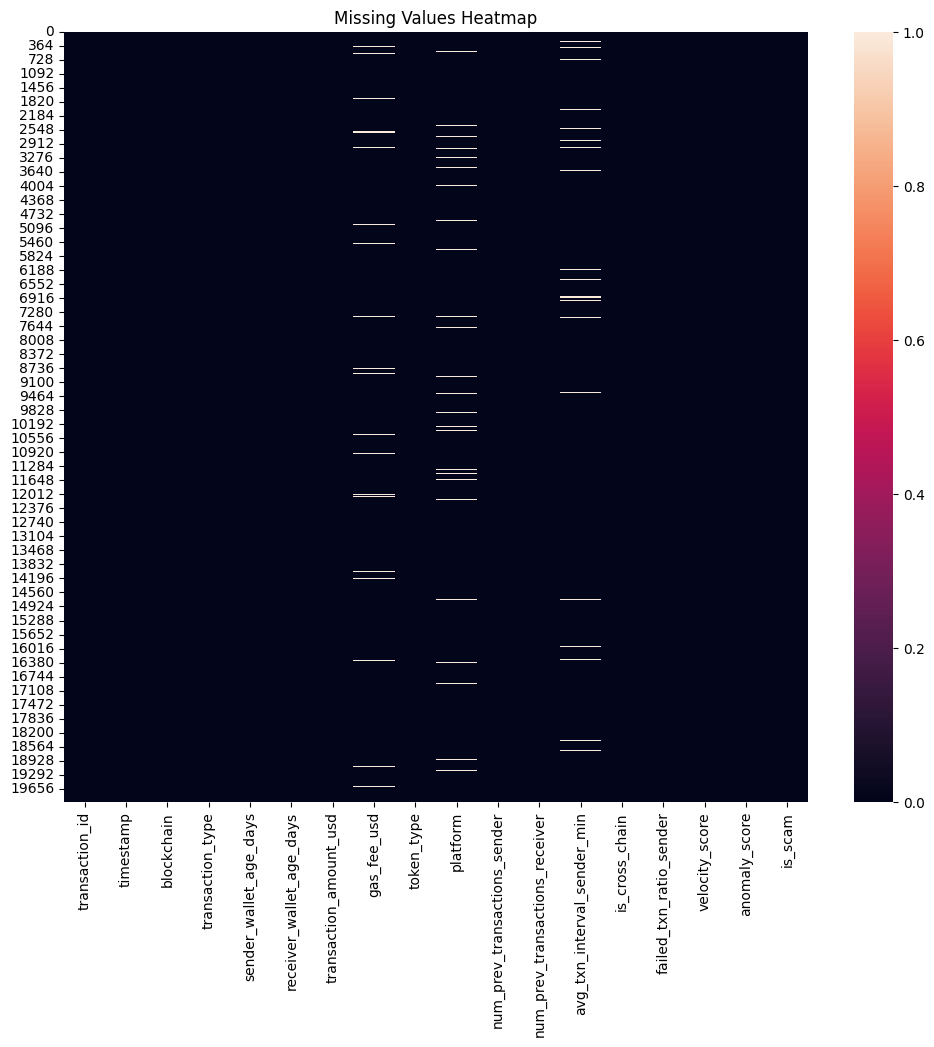

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(crypto.isnull(),cbar=True)
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
crypto.isnull().sum().sum()

np.int64(1800)

In [ ]:
crypto.duplicated().sum()

np.int64(0)

In [ ]:
fee_crypto = crypto['gas_fee_usd'].mean()
fee_crypto

np.float64(10.192139175257733)

In [ ]:
interval = crypto['avg_txn_interval_sender_min'].mean()
interval

np.float64(240.83610309278353)

In [ ]:
platform = crypto['platform'].mode()
platform

,platform
0,Binance


In [ ]:
crypto['is_scam'].value_counts()

,count
is_scam,
0,18550
1,1450


# **Data visualization**


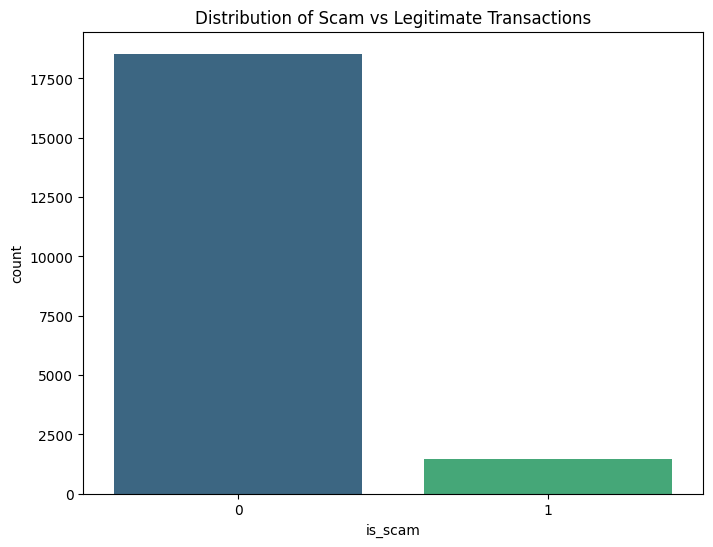

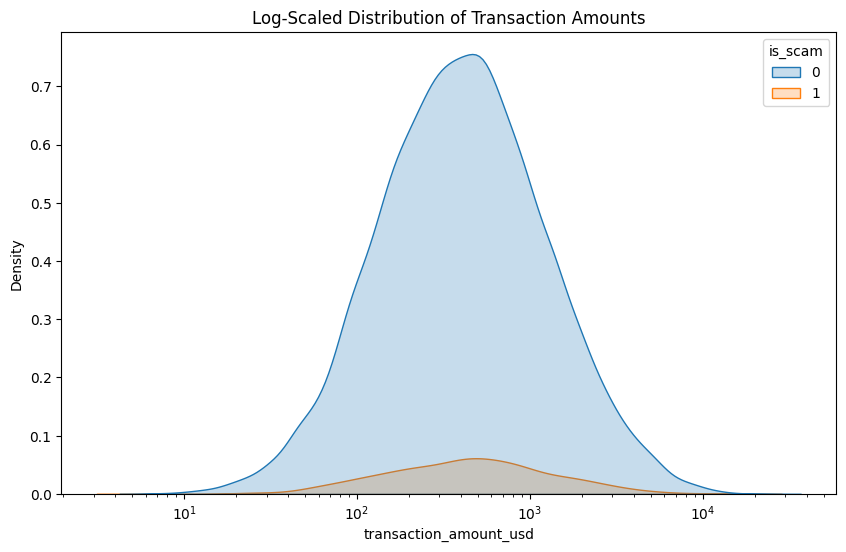

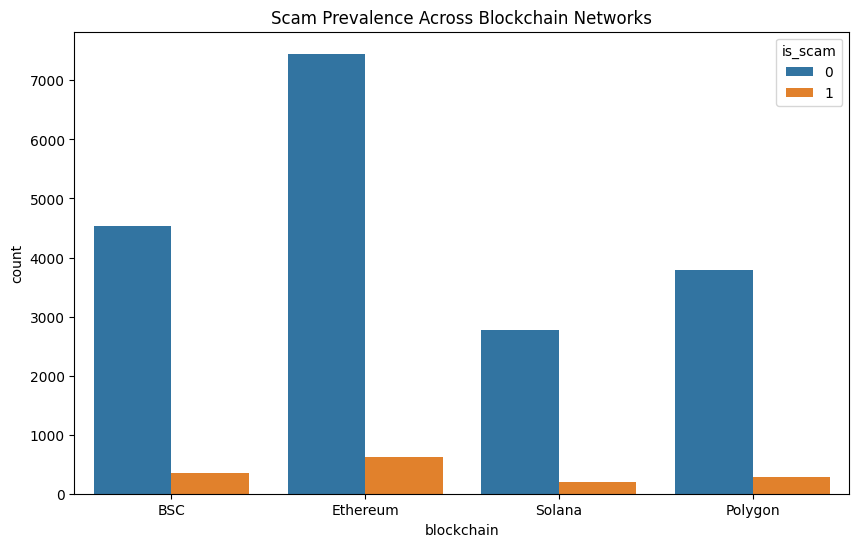

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='is_scam',data=crypto,palette='viridis')
plt.title('Distribution of Scam vs Legitimate Transactions')
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=crypto, x='transaction_amount_usd', hue='is_scam', fill=True, log_scale=True)
plt.title('Log-Scaled Distribution of Transaction Amounts')
plt.show()      # Distribution of Transaction Amounts by Scam


plt.figure(figsize=(10, 6))
sns.countplot(data=crypto, x='blockchain', hue='is_scam')
plt.title('Scam Prevalence Across Blockchain Networks')
plt.show()         # Categorical Analysis- Blockchain vs Scam frequency

**So from the above graph we can observe that 18550 are legitimate transactions and 1450 are scam transactions. That means we have trust on crypto market**

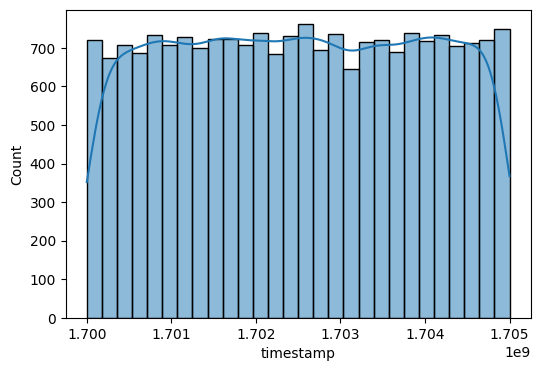

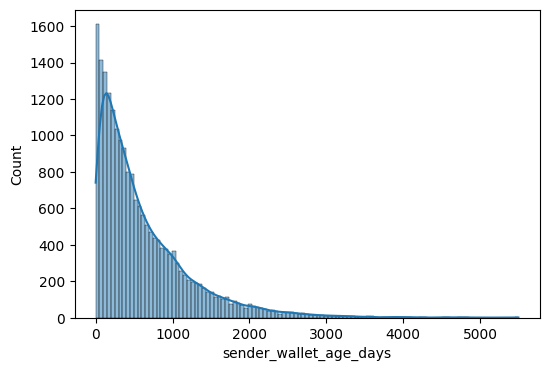

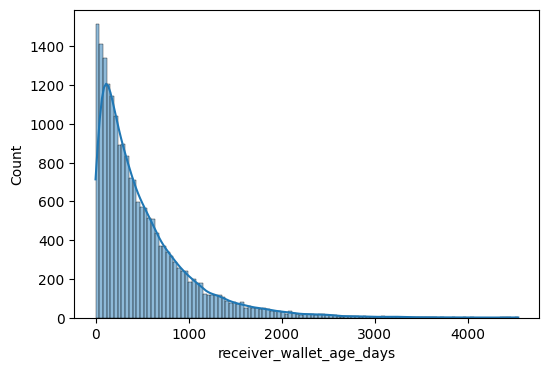

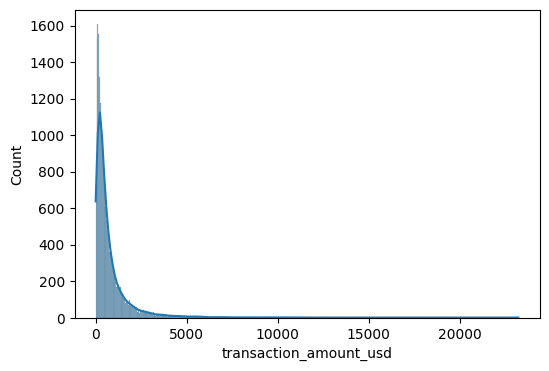

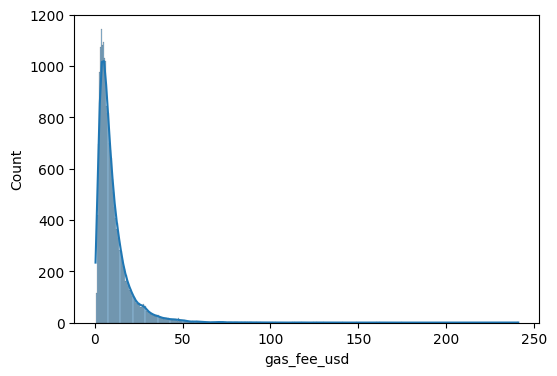

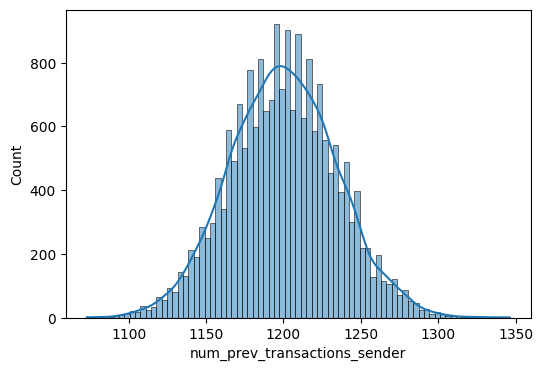

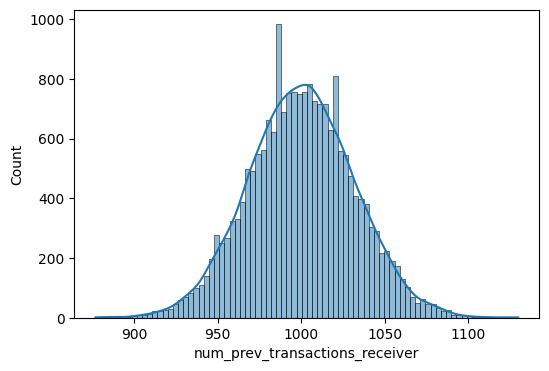

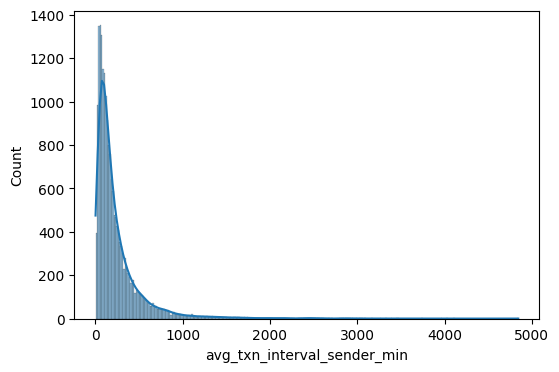

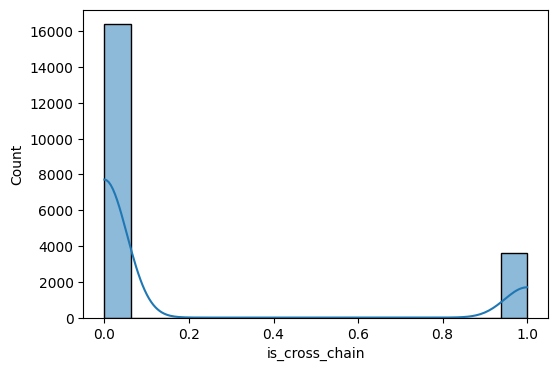

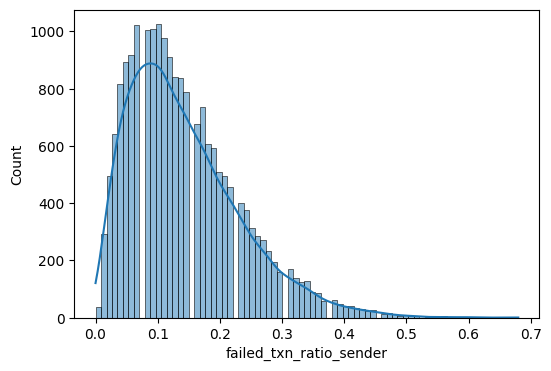

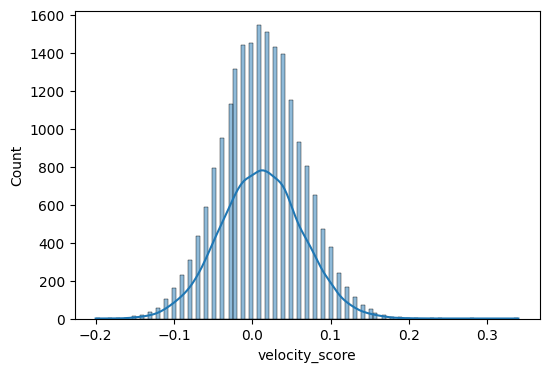

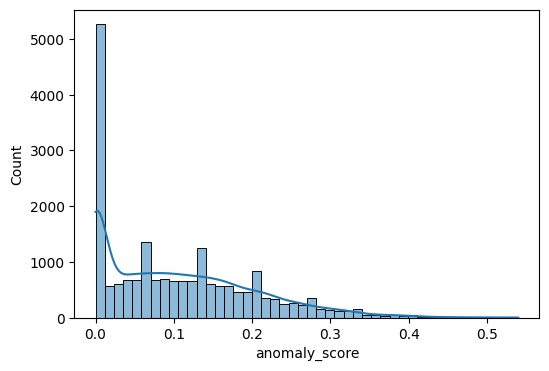

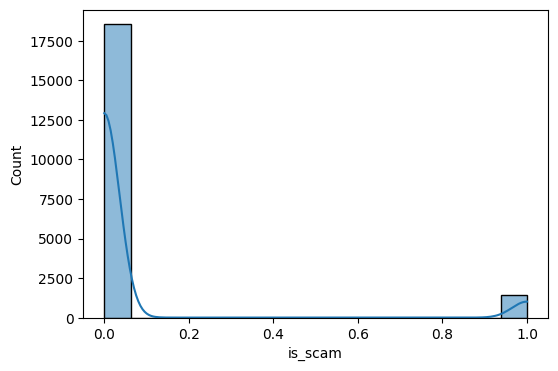

In [ ]:
numeric_cols = crypto.select_dtypes(include=['number']).columns
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(crypto[cols], kde=True)
  plt.show()

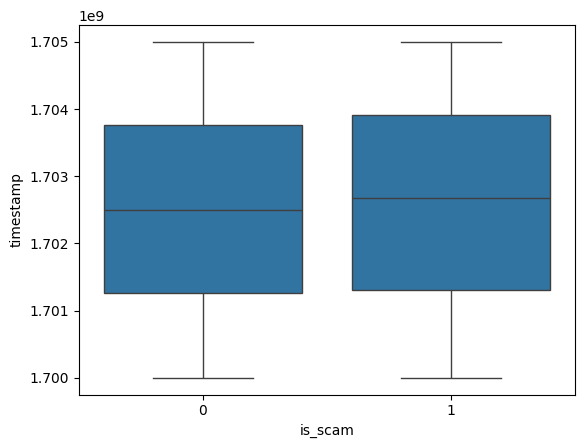

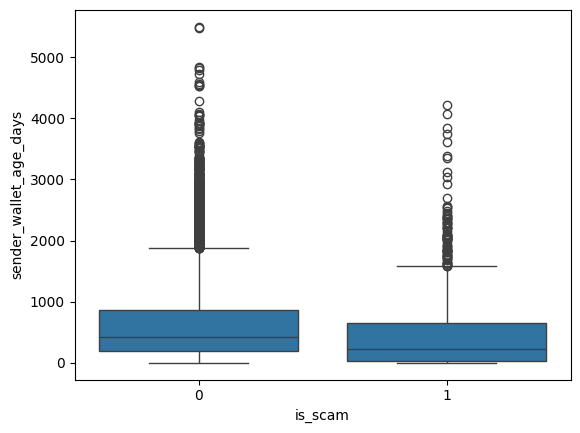

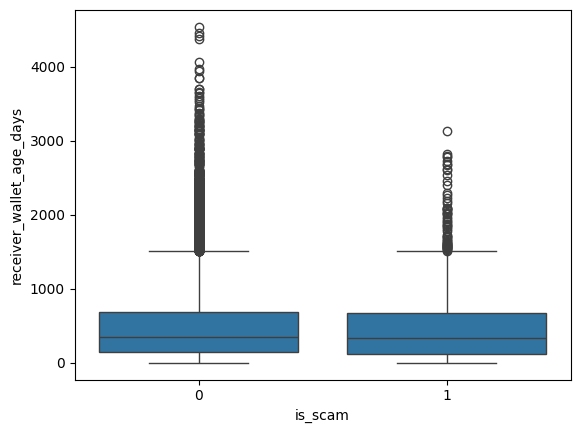

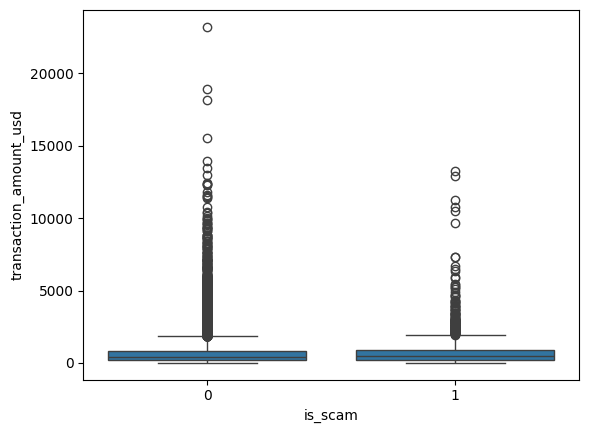

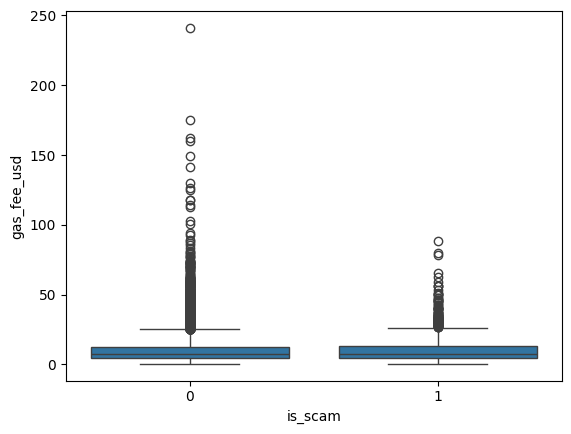

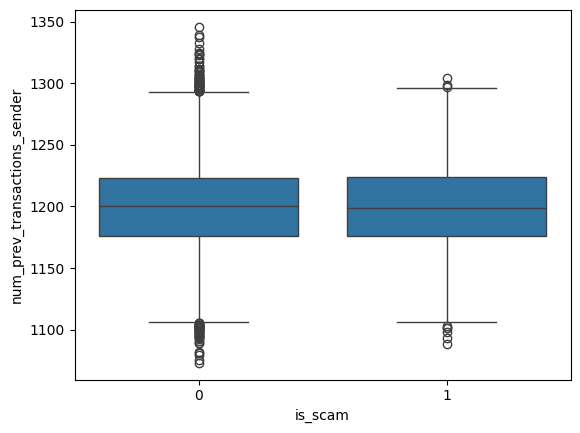

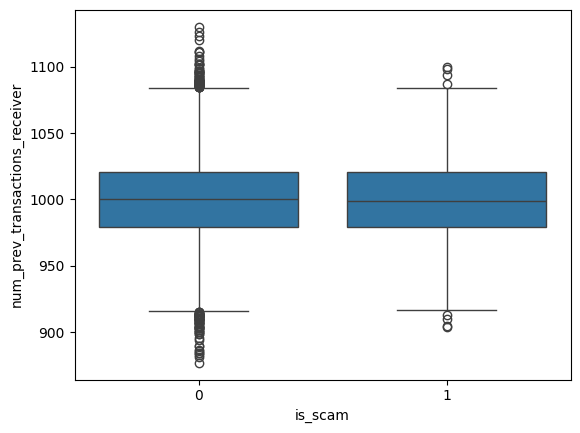

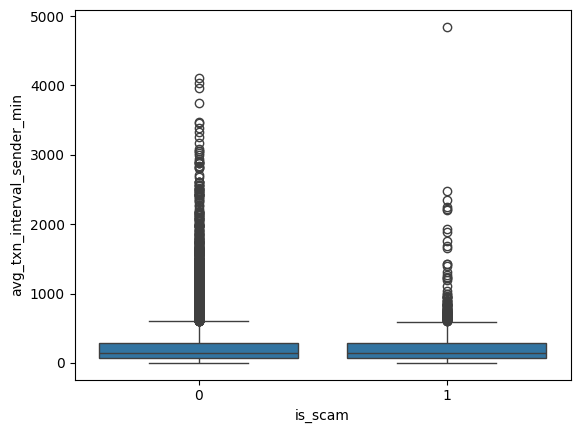

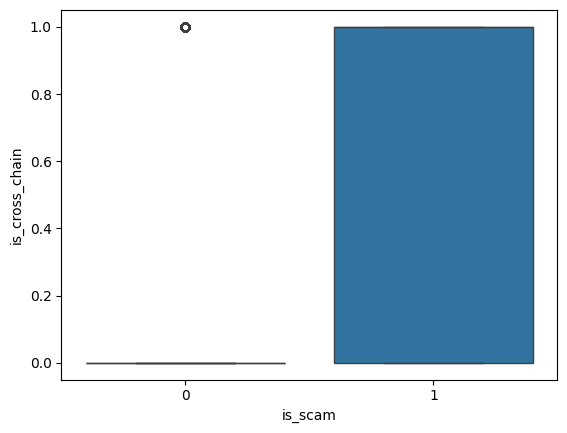

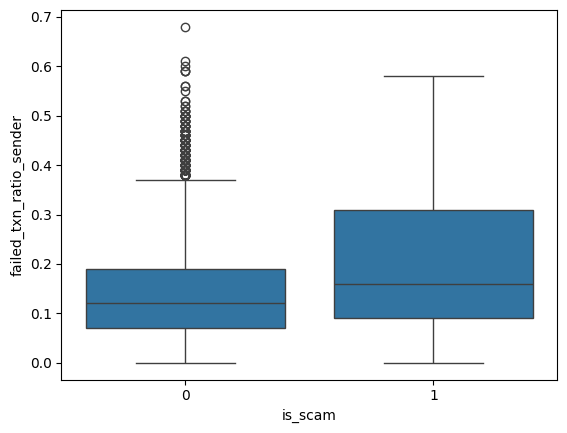

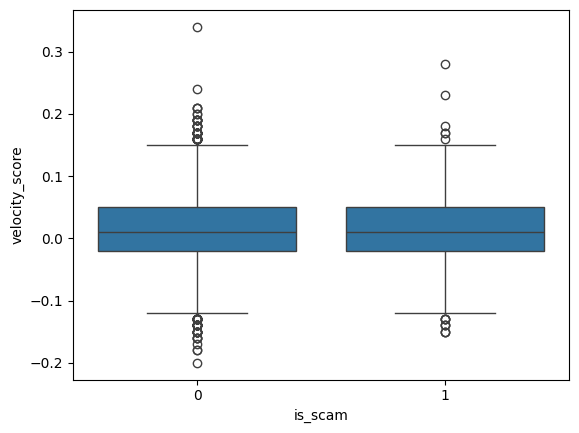

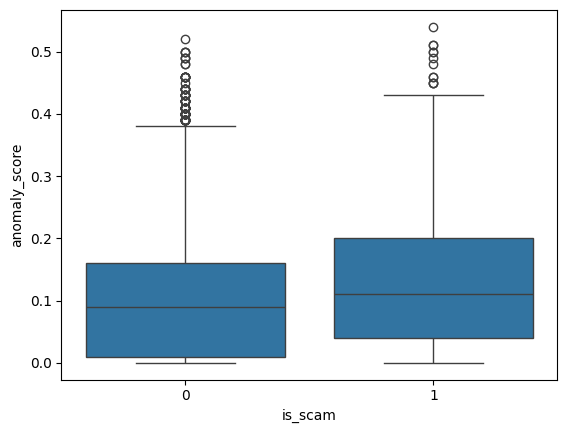

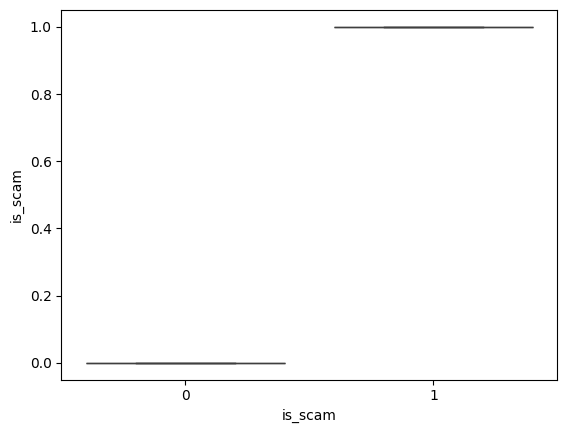

In [ ]:
for out_cols in numeric_cols:
  sns.boxplot(x=crypto['is_scam'],y=crypto[out_cols],data=crypto)
  plt.show()

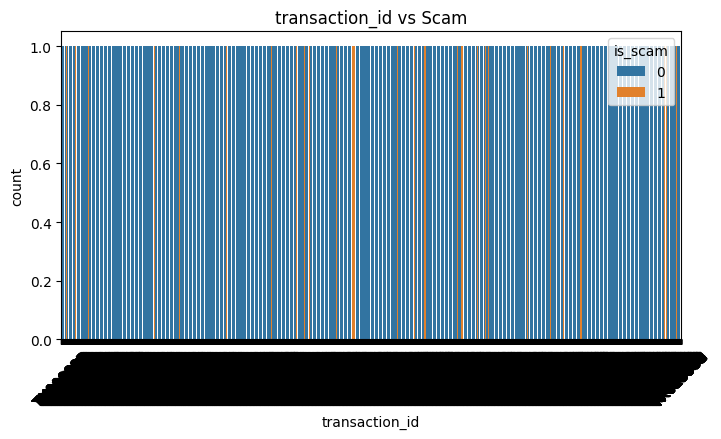

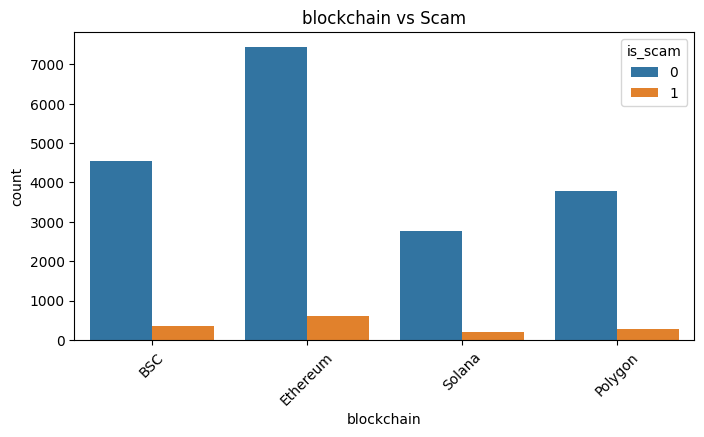

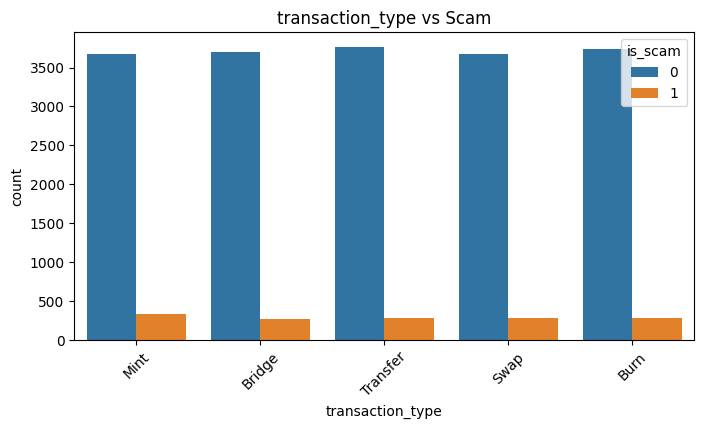

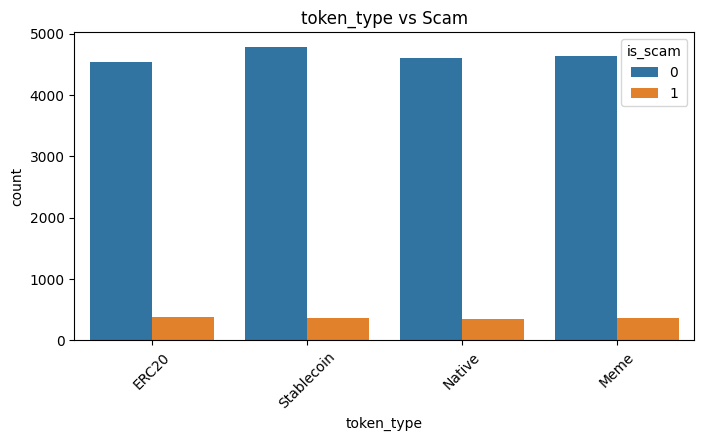

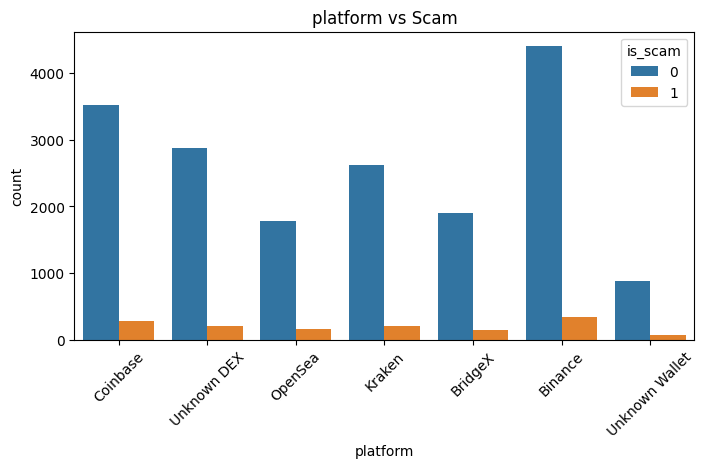

In [ ]:
cat_cols = crypto.select_dtypes(include=['object'])

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='is_scam', data=crypto)
    plt.title(f"{col} vs Scam")
    plt.xticks(rotation=45)
    plt.show()

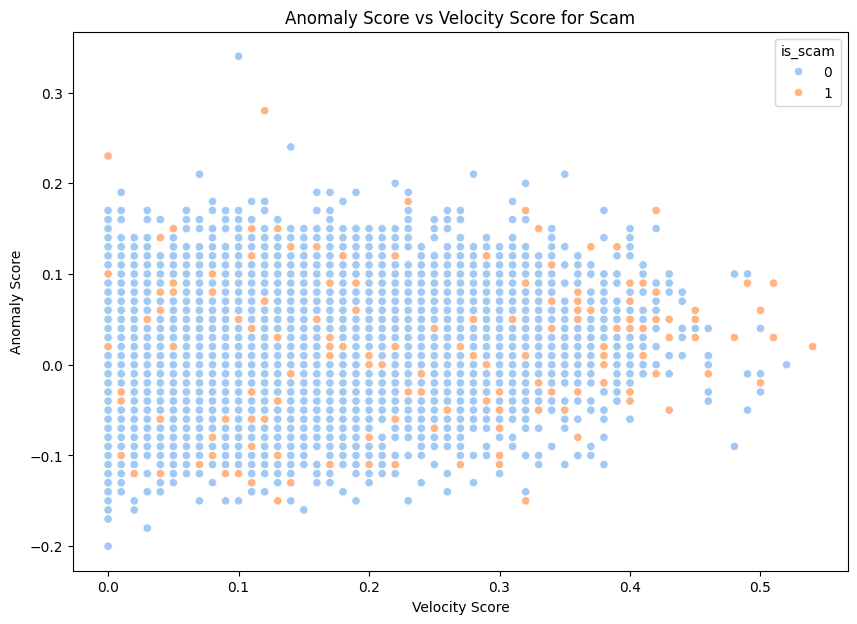

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(x='anomaly_score',y='velocity_score',hue='is_scam',data=crypto,palette='pastel')
plt.title('Anomaly Score vs Velocity Score for Scam')
plt.xlabel('Velocity Score')
plt.ylabel('Anomaly Score')
plt.show()

In [ ]:
gas_fee = crypto['gas_fee_usd'].mean()
avg_txn_interval_sender_min = crypto['avg_txn_interval_sender_min'].mean()

crypto['gas_fee_usd'].fillna(gas_fee,inplace=True)
crypto['avg_txn_interval_sender_min'].fillna(avg_txn_interval_sender_min,inplace=True)

crypto['gas_fee_usd'].isnull().sum()


np.int64(0)

In [ ]:
platform = crypto['platform'].mode()[0]

crypto['platform'].fillna(platform,inplace=True)

crypto['platform'].isnull().sum()

np.int64(0)

In [ ]:
crypto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  20000 non-null  object 
 1   timestamp                       20000 non-null  int64  
 2   blockchain                      20000 non-null  object 
 3   transaction_type                20000 non-null  object 
 4   sender_wallet_age_days          20000 non-null  int64  
 5   receiver_wallet_age_days        20000 non-null  int64  
 6   transaction_amount_usd          20000 non-null  float64
 7   gas_fee_usd                     20000 non-null  float64
 8   token_type                      20000 non-null  object 
 9   platform                        20000 non-null  object 
 10  num_prev_transactions_sender    20000 non-null  int64  
 11  num_prev_transactions_receiver  20000 non-null  int64  
 12  avg_txn_interval_sender_min     

**We are dropping the transaction_id column as it is not important for prediction yet**

In [ ]:
crypto = crypto.drop(columns=['transaction_id','timestamp'],errors='ignore')
crypto.shape

(20000, 16)

In [ ]:
crypto.head()

,blockchain,transaction_type,sender_wallet_age_days,receiver_wallet_age_days,transaction_amount_usd,gas_fee_usd,token_type,platform,num_prev_transactions_sender,num_prev_transactions_receiver,avg_txn_interval_sender_min,is_cross_chain,failed_txn_ratio_sender,velocity_score,anomaly_score,is_scam
0,BSC,Mint,469,769,929.39,2.76,ERC20,Coinbase,1120,960,100.5,0,0.18,-0.12,0.11,0
1,Ethereum,Bridge,1076,1238,139.21,9.36,Stablecoin,Unknown DEX,1203,1011,170.9,1,0.01,0.01,0.10,1
2,BSC,Transfer,679,442,395.21,13.44,Native,OpenSea,1160,1054,7.7,1,0.14,0.10,0.12,0
3,Solana,Mint,1573,2434,2078.90,1.29,Stablecoin,Coinbase,1179,994,6.1,0,0.07,0.13,0.00,0
4,BSC,Swap,522,418,72.47,24.68,Stablecoin,Kraken,1177,968,194.7,0,0.30,0.01,0.20,0


**We are converting labels of some columns into int for Standardization**

In [ ]:
cat_cols = crypto.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    crypto[col] = le.fit_transform(crypto[col])

cat_cols

Index(['blockchain', 'transaction_type', 'token_type', 'platform'], dtype='object')

In [ ]:
crypto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   blockchain                      20000 non-null  int64  
 1   transaction_type                20000 non-null  int64  
 2   sender_wallet_age_days          20000 non-null  int64  
 3   receiver_wallet_age_days        20000 non-null  int64  
 4   transaction_amount_usd          20000 non-null  float64
 5   gas_fee_usd                     20000 non-null  float64
 6   token_type                      20000 non-null  int64  
 7   platform                        20000 non-null  int64  
 8   num_prev_transactions_sender    20000 non-null  int64  
 9   num_prev_transactions_receiver  20000 non-null  int64  
 10  avg_txn_interval_sender_min     20000 non-null  float64
 11  is_cross_chain                  20000 non-null  int64  
 12  failed_txn_ratio_sender         

In [ ]:
crypto.head()

,blockchain,transaction_type,sender_wallet_age_days,receiver_wallet_age_days,transaction_amount_usd,gas_fee_usd,token_type,platform,num_prev_transactions_sender,num_prev_transactions_receiver,avg_txn_interval_sender_min,is_cross_chain,failed_txn_ratio_sender,velocity_score,anomaly_score,is_scam
0,0,2,469,769,929.39,2.76,0,2,1120,960,100.5,0,0.18,-0.12,0.11,0
1,1,0,1076,1238,139.21,9.36,3,5,1203,1011,170.9,1,0.01,0.01,0.10,1
2,0,4,679,442,395.21,13.44,2,4,1160,1054,7.7,1,0.14,0.10,0.12,0
3,3,2,1573,2434,2078.90,1.29,3,2,1179,994,6.1,0,0.07,0.13,0.00,0
4,0,3,522,418,72.47,24.68,3,3,1177,968,194.7,0,0.30,0.01,0.20,0


In [ ]:
X = crypto.drop(['is_scam'],axis=1)
Y = crypto['is_scam']
X.shape, Y.shape

((20000, 15), (20000,))

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
x_scaled_df = pd.DataFrame(x_scaled)
x_scaled_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-1.270687,-0.002225,-0.226236,0.531399,0.169842,-0.763957,-1.353720,-0.181415,-2.313655,-1.276851,-0.476130,-0.468521,0.420138,-2.529088,0.065752
1,-0.258953,-1.415189,0.786216,1.460327,-0.564705,-0.085536,1.323556,1.373129,0.086939,0.341137,-0.237278,2.134375,-1.465605,-0.029087,-0.038625
2,-1.270687,1.410738,0.124036,-0.116276,-0.326729,0.333851,0.431131,0.854947,-1.156742,1.705323,-0.790981,2.134375,-0.023566,1.701684,0.170129
3,1.764514,-0.002225,1.615191,3.829194,1.238419,-0.915060,1.323556,-0.181415,-0.607209,-0.198192,-0.796409,-0.468521,-0.800048,2.278607,-1.082391
4,-1.270687,0.704256,-0.137834,-0.163812,-0.626746,1.489222,1.323556,0.336766,-0.665054,-1.023049,-0.156530,-0.468521,1.751250,-0.029087,1.005142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.752780,-0.002225,-0.711612,-0.847139,3.609777,0.050148,-0.461295,0.336766,0.144785,-1.689279,-0.756375,-0.468521,-0.800048,0.740145,-1.082391
19996,1.764514,0.704256,-0.306298,2.924033,1.038585,-0.149267,-1.353720,0.854947,-0.693977,0.785291,-0.502594,-0.468521,-0.578196,-0.606010,-0.560508
19997,-1.270687,0.704256,-0.649898,-0.730280,-0.260598,-0.746483,1.323556,0.336766,-0.144443,0.055610,2.421309,2.134375,-0.134492,-0.221394,1.109518
19998,-0.258953,-1.415189,-0.466422,-0.441104,-0.284841,-0.766013,0.431131,0.336766,-1.445971,-0.134742,-0.516505,-0.468521,-1.021901,0.740145,-1.082391


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x_scaled_df,Y,test_size=0.2,random_state=42)
xtrain.shape, xtest.shape, ytrain.shape

((16000, 15), (4000, 15), (16000,))

In [ ]:
rfc = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',random_state=42)
rfc.fit(xtrain,ytrain)



RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [ ]:
prediction = rfc.predict(xtest)


In [ ]:
accuracy_score(ytest,prediction)

0.82025

In [ ]:
com = confusion_matrix(ytest, prediction)

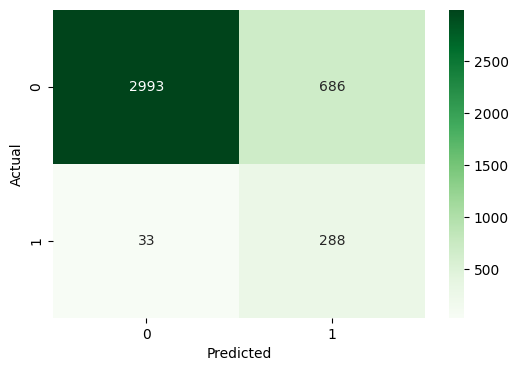

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(com,annot=True,fmt='d',cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(ytest, prediction))

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      3679
           1       0.30      0.90      0.44       321

    accuracy                           0.82      4000
   macro avg       0.64      0.86      0.67      4000
weighted avg       0.93      0.82      0.86      4000



In [ ]:
y = Y.astype(str)
y

,is_scam
0,0
1,1
2,0
3,0
4,0
...,...
19995,0
19996,0
19997,1
19998,0


In [ ]:
neg = ytrain.value_counts()[0]
pos = ytrain.value_counts()[1]

scale_pos_weight = neg / pos
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 13.171833480956598


In [ ]:

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(xtrain, ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(xtest)


In [ ]:
cm =confusion_matrix(ytest,xgb_pred)

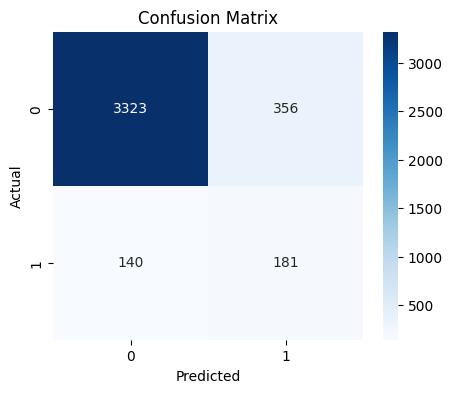

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy_score(ytest,xgb_pred)

0.876

In [ ]:
print(classification_report(ytest,xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      3679
           1       0.34      0.56      0.42       321

    accuracy                           0.88      4000
   macro avg       0.65      0.73      0.68      4000
weighted avg       0.91      0.88      0.89      4000



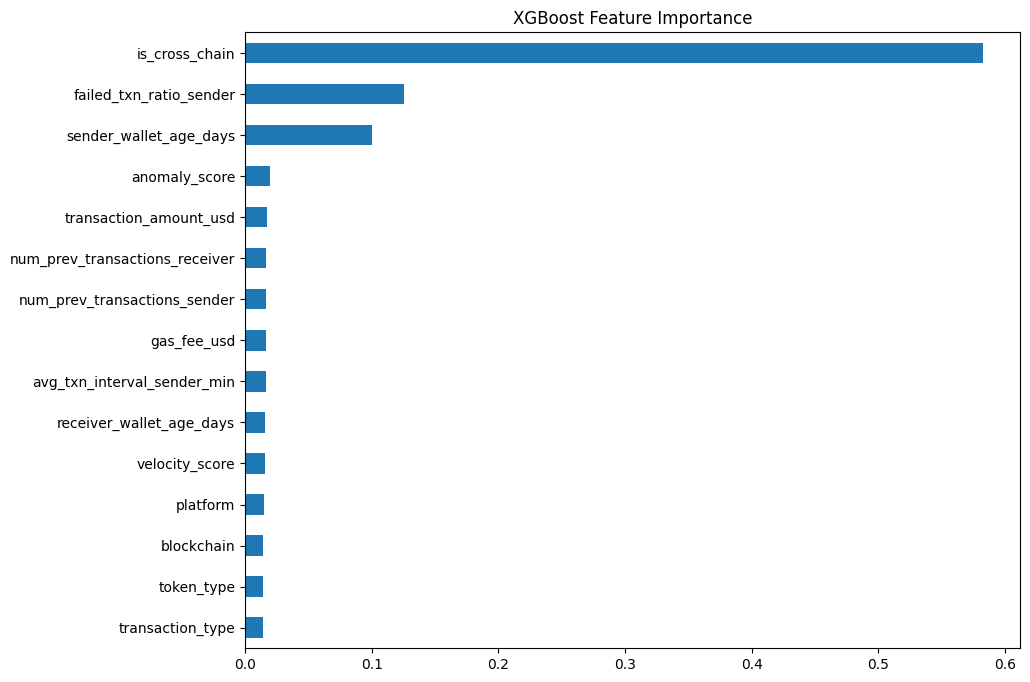

In [ ]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,8))
plt.title("XGBoost Feature Importance")
plt.show()

**This tells us:**

> Which features are driving scam detection

> Which features are useless

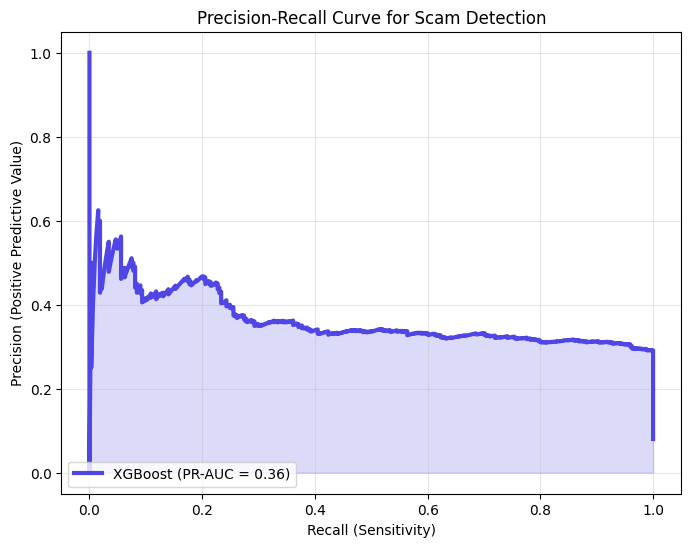

In [ ]:
# 3. Precision-Recall Curve
# This is crucial for imbalanced data to see the trade-off between Precision and Recall
from sklearn.metrics import precision_recall_curve, auc
y_scores = xgb.predict_proba(xtest)[:, 1]
precision, recall, thresholds = precision_recall_curve(ytest, y_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (PR-AUC = {pr_auc:.2f})', color='#4F46E5', lw=3)
plt.fill_between(recall, precision, alpha=0.2, color='#4F46E5')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve for Scam Detection')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

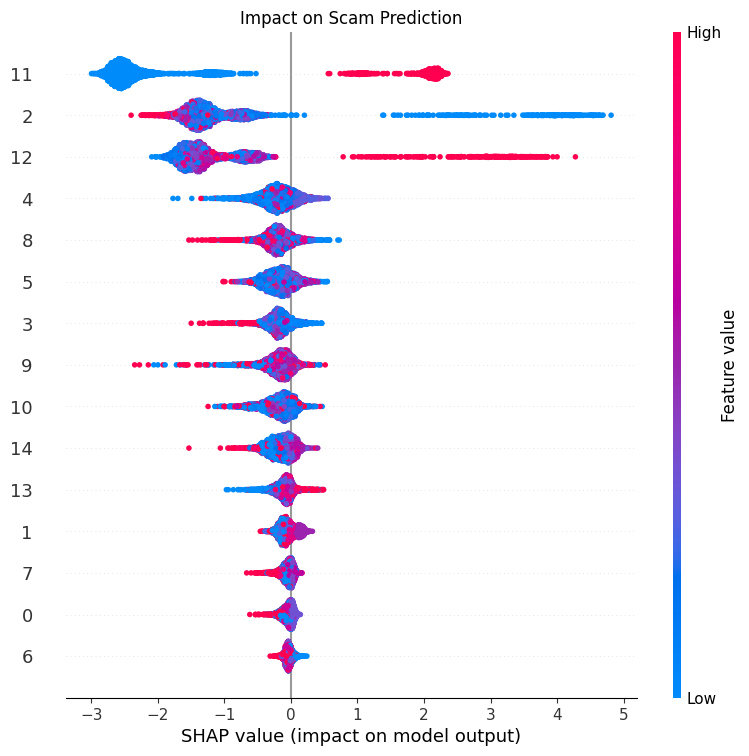

In [ ]:
import shap
# 4. SHAP Explanations (Explainability)
# This shows the contribution of each feature to the model's output
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(xtest)

# Summary Plot: Overall feature importance and direction
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, xtest, show=False)
plt.title('Impact on Scam Prediction')
plt.show()

# Task
The XGBoost model currently uses a default classification threshold (typically 0.5) to classify transactions as either legitimate (0) or scam (1). Let's analyze the impact of this default threshold on false positives and false negatives based on the provided classification report and confusion matrix.

The confusion matrix for the XGBoost model at the default threshold is:
```
[[3323,  356],
 [ 140,  181]]
```
From this, we can interpret:
*   **True Negatives (TN)**: 3323 legitimate transactions were correctly identified as legitimate.
*   **False Positives (FP)**: 356 legitimate transactions were incorrectly classified as scams. These are "false alarms."
*   **False Negatives (FN)**: 140 actual scam transactions were incorrectly classified as legitimate. These are "missed scams."
*   **True Positives (TP)**: 181 actual scam transactions were correctly identified as scams.

The classification report for the XGBoost model at the default threshold is:
```
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      3679
           1       0.34      0.56      0.42       321

    accuracy                           0.88      4000
   macro avg       0.65      0.73      0.68      4000
weighted avg       0.91      0.88      0.89      4000
```
**Impact of Current Threshold:**
*   **High False Positives (356 FP)**: The precision for class 1 (scam) is 0.34. This means that only 34% of the transactions flagged as scams are actually scams. A high number of false positives can lead to significant operational overhead (e.g., manual review of legitimate transactions, customer dissatisfaction due to blocked funds).
*   **Moderate False Negatives (140 FN)**: The recall for class 1 (scam) is 0.56. This means the model is only catching 56% of the actual scam transactions. In a fraud detection scenario, missed scams can result in substantial financial losses for users or the platform.

There's a clear trade-off: to reduce costly false negatives (missed scams), we might need to tolerate more false positives (false alarms), and vice versa. Given that missing a scam is often more detrimental than flagging a legitimate transaction falsely, we might want to adjust the threshold to improve recall for the scam class.

Let's now explore how adjusting the classification threshold impacts these metrics. We'll calculate predicted probabilities and then experiment with different thresholds.


   

## Analyze Current Threshold Impact



this model rn XGBoost model, using the default classification threshold of 0.5,presenting the following performance characteristics whch we can confirm though the confusion matrix and classification report:

**Confusion Matrix:**
*   **True Negatives (TN):** 3323 (Legitimate transactions correctly identified)
*   **False Positives (FP):** 356 (Legitimate transactions incorrectly flagged as scam)
*   **False Negatives (FN):** 140 (Scam transactions incorrectly missed by the model)
*   **True Positives (TP):** 181 (Scam transactions correctly identified)

**Classification Report (for 'scam' class, i.e., class 1):**
*   **Precision (Class 1):** 0.34
*   **Recall (Class 1):** 0.56

**Impact of Default Threshold (0.5):**

1.  **False Positives (FP):** With 356 false positives, the model incorrectly flags a significant number of legitimate transactions as scams. This leads to a low precision score of 0.34 for the scam class. A low precision indicates that when the model predicts a transaction is a scam, it is only correct about 34% of the time. In a real-world scenario, this could lead to many legitimate users being inconvenienced or having their transactions blocked unnecessarily.(ignore if already seen etc kinda of emails or text msgs)

2.  **False Negatives (FN):** model has **140** false negatives, meaning it fails to identify 140 actual scam transactions. This contributes to a recall score of 0.56 for the scam class. A recall of 0.56 means the model is able to detect only 56% of all actual scam transactions. While better than precision, a substantial number of scams are still slipping through the detection system.

**Conclusion:**
The default threshold of 0.5 results in a trade-off where the model has a moderate ability to detect scams (recall = 0.56) but at the cost of flagging many legitimate transactions incorrectly (low precision = 0.34). This suggests that the current threshold might not be optimal, especially if the cost of false positives (inconvenience to users) or false negatives (financial loss from scams) needs to be prioritized. Depending on the business objective, a different threshold might be needed to balance precision and recall more effectively.

**Action plan**
* First, calculating the predicted probabilities for the positive class (scam) on the `xtest` dataset using the `xgb.predict_proba()` method. Then,will define a range of thresholds and iterate through them, making predictions, calculating confusion matrices, and printing relevant metrics from the classification report for each threshold.



In [ ]:
y_pred_proba = xgb.predict_proba(xtest)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    cm_threshold = confusion_matrix(ytest, y_pred_threshold)

    print(f"\n--- Threshold: {threshold:.1f} ---")
    print("Confusion Matrix:")
    print(cm_threshold)

    report_threshold = classification_report(ytest, y_pred_threshold, output_dict=True)
    print(f"Precision (Scam): {report_threshold['1']['precision']:.2f}")
    print(f"Recall (Scam): {report_threshold['1']['recall']:.2f}")
    print(f"F1-Score (Scam): {report_threshold['1']['f1-score']:.2f}")


--- Threshold: 0.1 ---
Confusion Matrix:
[[2937  742]
 [  10  311]]
Precision (Scam): 0.30
Recall (Scam): 0.97
F1-Score (Scam): 0.45

--- Threshold: 0.2 ---
Confusion Matrix:
[[3015  664]
 [  23  298]]
Precision (Scam): 0.31
Recall (Scam): 0.93
F1-Score (Scam): 0.46

--- Threshold: 0.3 ---
Confusion Matrix:
[[3101  578]
 [  61  260]]
Precision (Scam): 0.31
Recall (Scam): 0.81
F1-Score (Scam): 0.45

--- Threshold: 0.4 ---
Confusion Matrix:
[[3215  464]
 [  95  226]]
Precision (Scam): 0.33
Recall (Scam): 0.70
F1-Score (Scam): 0.45

--- Threshold: 0.5 ---
Confusion Matrix:
[[3323  356]
 [ 140  181]]
Precision (Scam): 0.34
Recall (Scam): 0.56
F1-Score (Scam): 0.42

--- Threshold: 0.6 ---
Confusion Matrix:
[[3435  244]
 [ 195  126]]
Precision (Scam): 0.34
Recall (Scam): 0.39
F1-Score (Scam): 0.36

--- Threshold: 0.7 ---
Confusion Matrix:
[[3526  153]
 [ 232   89]]
Precision (Scam): 0.37
Recall (Scam): 0.28
F1-Score (Scam): 0.32

--- Threshold: 0.8 ---
Confusion Matrix:
[[3612   67]
 [ 264 

##  Trade-offs and opportunity costs**

plotting precision-recall curve or a plot showing precision, recall, and F1-score across various thresholds, to visualize the trade-offs between reducing false positives and false negatives as the threshold changes, to arrive at OPTIMAL threshold.



To visualize the trade-offs of precision, recall, and F1-score across different thresholds, we will iterate through the previously defined thresholds, calculate these metrics for the scam class, store them in lists, and then plot them against the thresholds.



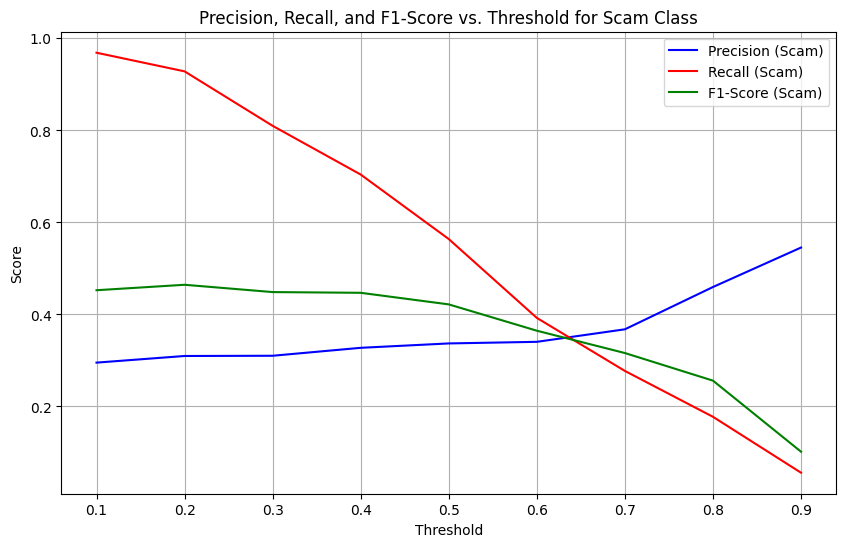

In [ ]:
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    report_threshold = classification_report(ytest, y_pred_threshold, output_dict=True)

    precision_scores.append(report_threshold['1']['precision'])
    recall_scores.append(report_threshold['1']['recall'])
    f1_scores.append(report_threshold['1']['f1-score'])

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision (Scam)', color='blue')
plt.plot(thresholds, recall_scores, label='Recall (Scam)', color='red')
plt.plot(thresholds, f1_scores, label='F1-Score (Scam)', color='green')

plt.title('Precision, Recall, and F1-Score vs Threshold for Scam Class')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()




 refering the findings we have arrived at regarding threshold adjustment we can now go for a suitable threshold based on the trade-offs, knowing how this impacts the reduction of false positives and false negatives.


## Summary:


*   **Summary of findings regarding threshold adjustment:**
    by analysis of different classification thresholds for the XGBoost model we now know the clear trade-off between precision and recall for the scam class.
    * trade off- can see clear inverse relationship between precision and recall for scam class, so increasing the TH raises precision and lowers recall
    * Previous TH-
      * scam recall- 0.56(missing 1401 scam)
      * Scam precision- 0.34(356 correct transactions flagged incorrectly)
    * lowering the TH
      * increases sensitivity, improving recall to 0.97 but precision come down to 0.30
    * Raising TH-
      * Improvs precision but reduces recall
      * i.e fewer false (+)ves and more false (-)
      ves    

* going with TH 0.3 as prioritizing the scams over precison for legetimate transactions, as for us missing scams is detrimental , so now **flase (-)ive flase to 84** from 140 with TH 0.5



### Insights

*   Further we can now evaluate the cost implications: Quantify the exact financial and operational costs associated with false positives (like we did in customer churn) versus false negatives (e.g. direct financial loss from scams) to fine-tune the optimal threshold or explore more advanced cost-sensitive learning approaches.
